#  Evolutionary Multiple-objective Optimization (part for 4.0)

- This script is for those who want to improve their final grade from 3.0 to 4.0. 
- Your task is to implement any one evolutionary algorithm for multiple-objective optimization introduced during the lecture (NSGA-II/NSGA-III/MOEA/D; except for NSGA).
- Note that it has to be your implementation (using external libraries is forbidden; EXCEPTION: you can use the JECDM framework: https://jecdm.cs.put.poznan.pl -- but it is a relatively complex software, and much effort must be spent to understand how to use it).
- The problem to be solved is the portfolio optimization tackled during lab 1.
- You can use the same data and price predictions as you made for lab 1 (Bundle1.zip) or update them accordingly to the next stage if you participate in the portfolio game (it is up to you).
- Apart from the two-objective scenario, tackle also a three-objective one. As for the third objective, think about some reasonable risk-measure. E.g., you can maximize the number of non-zero weights, which should refer to minimizing risk by diversifying investments.
- Perform experimental evaluation of your implementation. You can use, e.g., the IDG or the HV metric to quantify the quality of populations constructed by the method.
- The experimental evaluation should be "reasonably extensive." E.g., run your method multiple times and average the results, show average convergence plots, do the sensitivity analysis (just four combinations of population size/generations will be enough), and depict some final populations. Also, compare the populations (only for 2D scenarios) with those generated by the ECM or WSM algorithm. Note that ECM and WSM already generate Pareto optimal solutions, so these can be considered good benchmarks for comparison.
- You can report your results here, i.e., in the jupyter notebook. You do not need to prepare any pdf report, etc. 

In [1]:
from utils.MOO_utilities import *

In [2]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

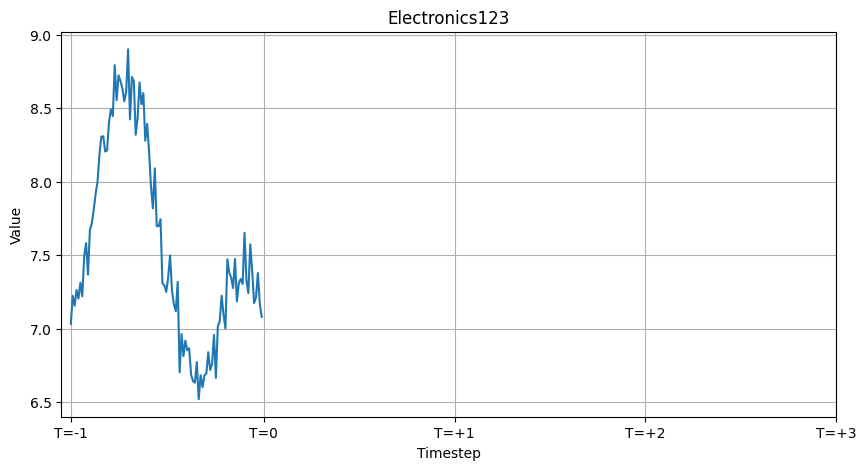

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

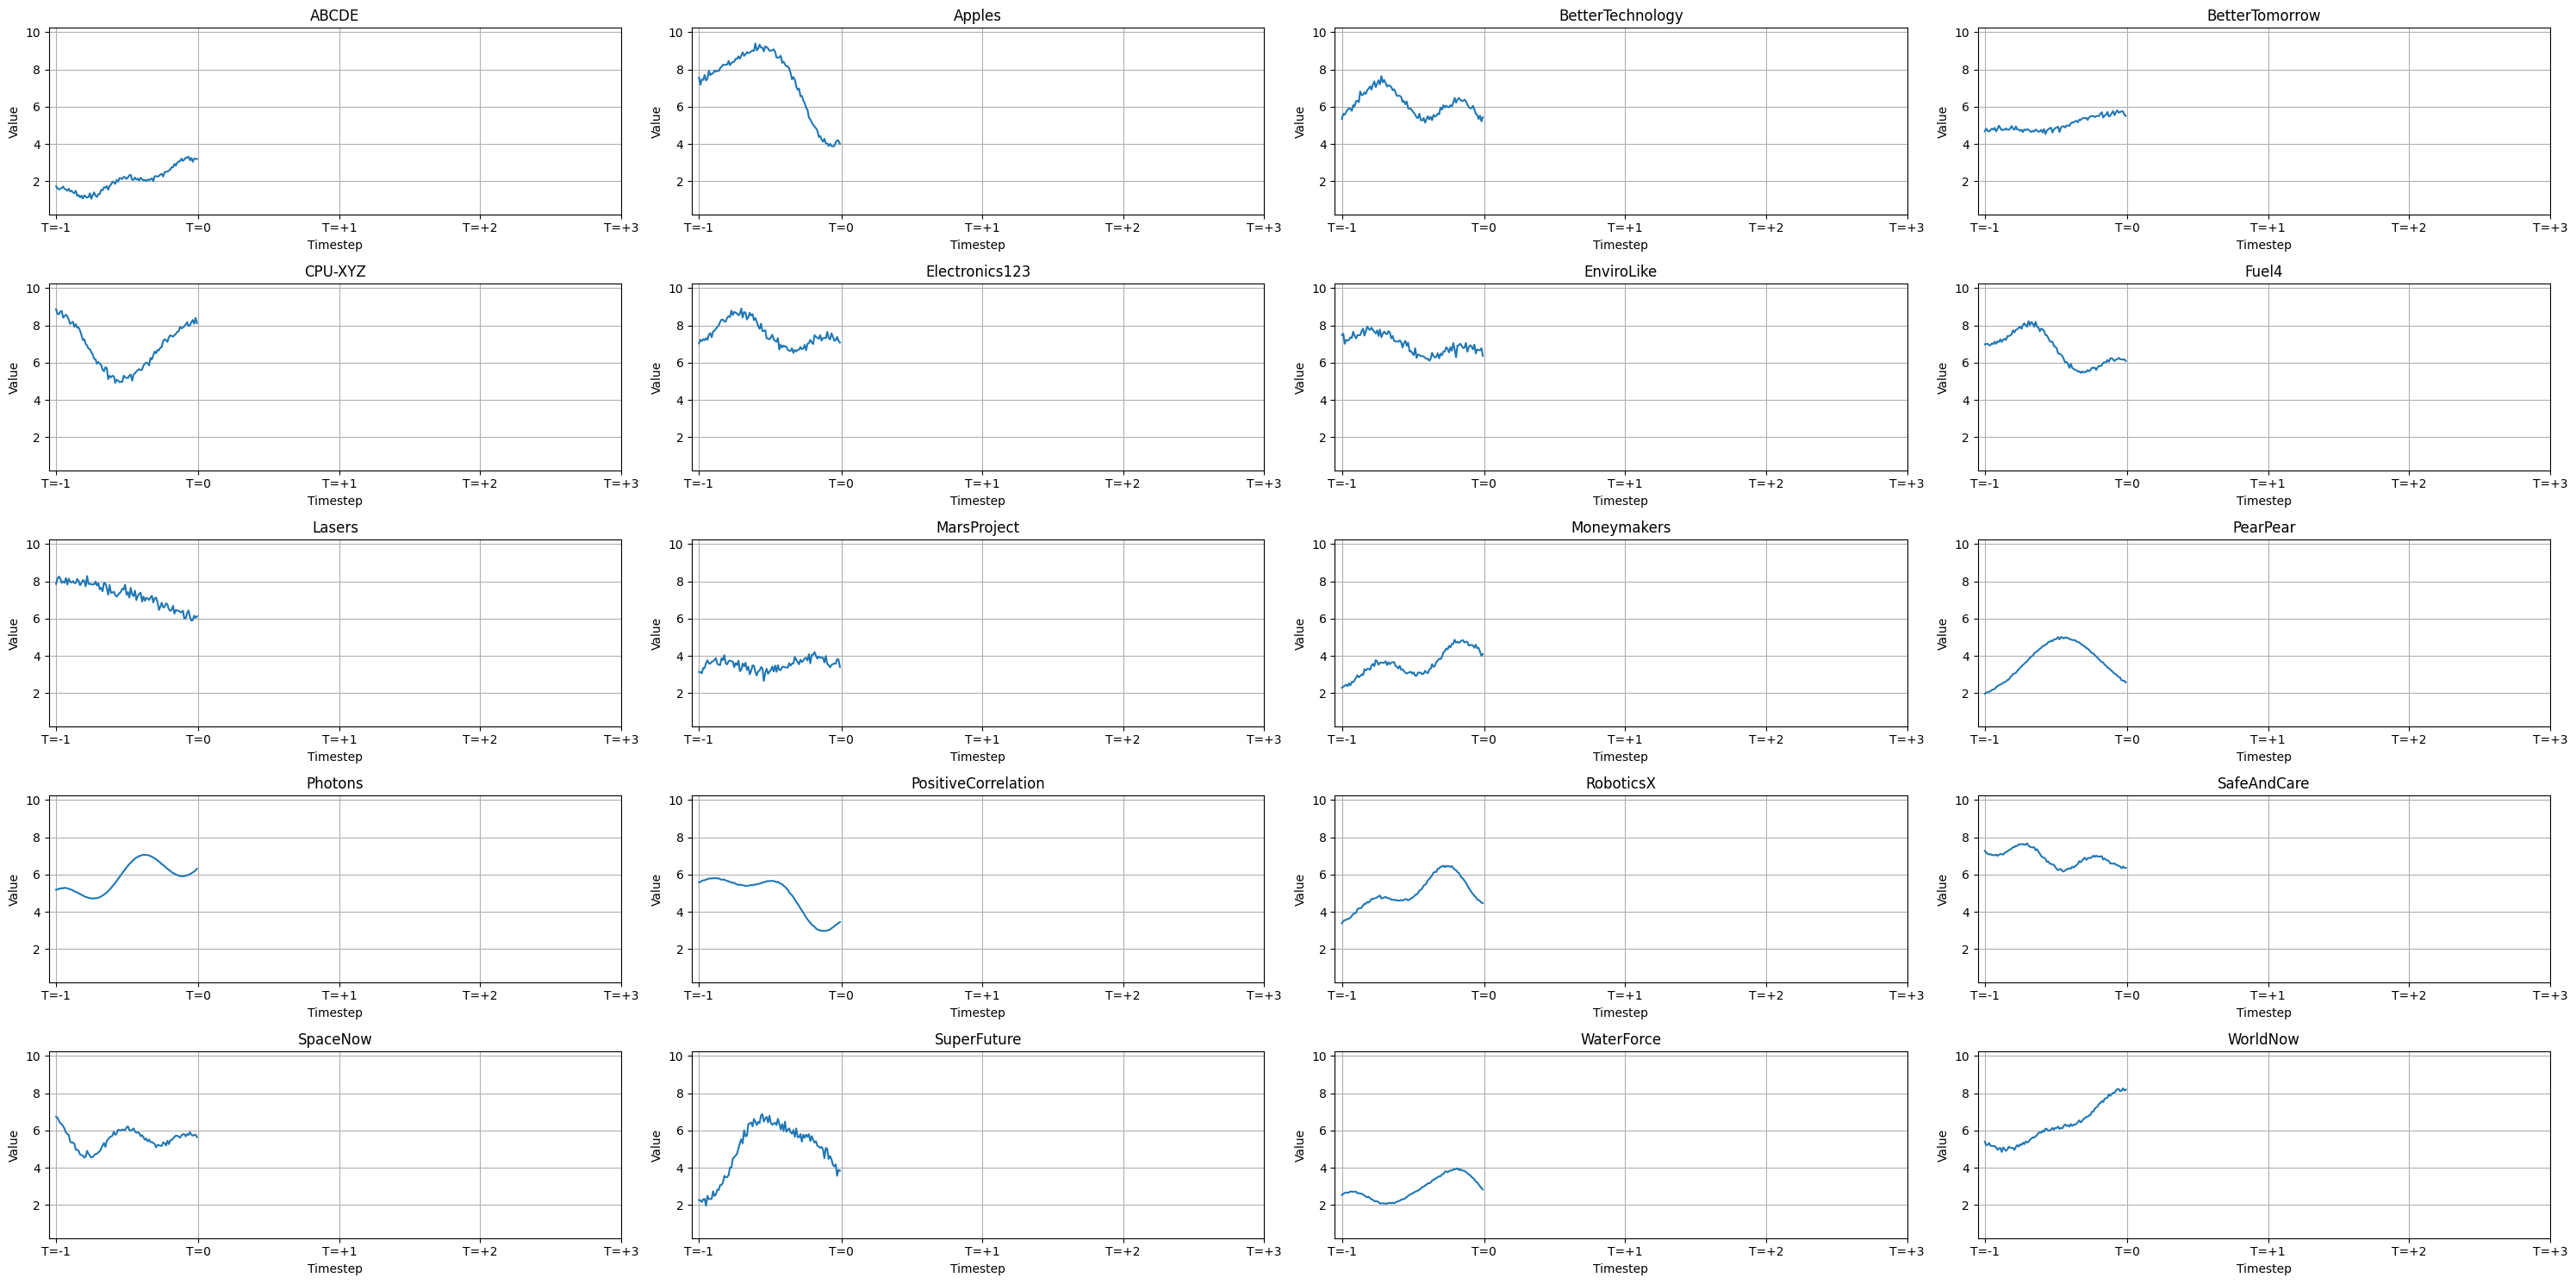

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

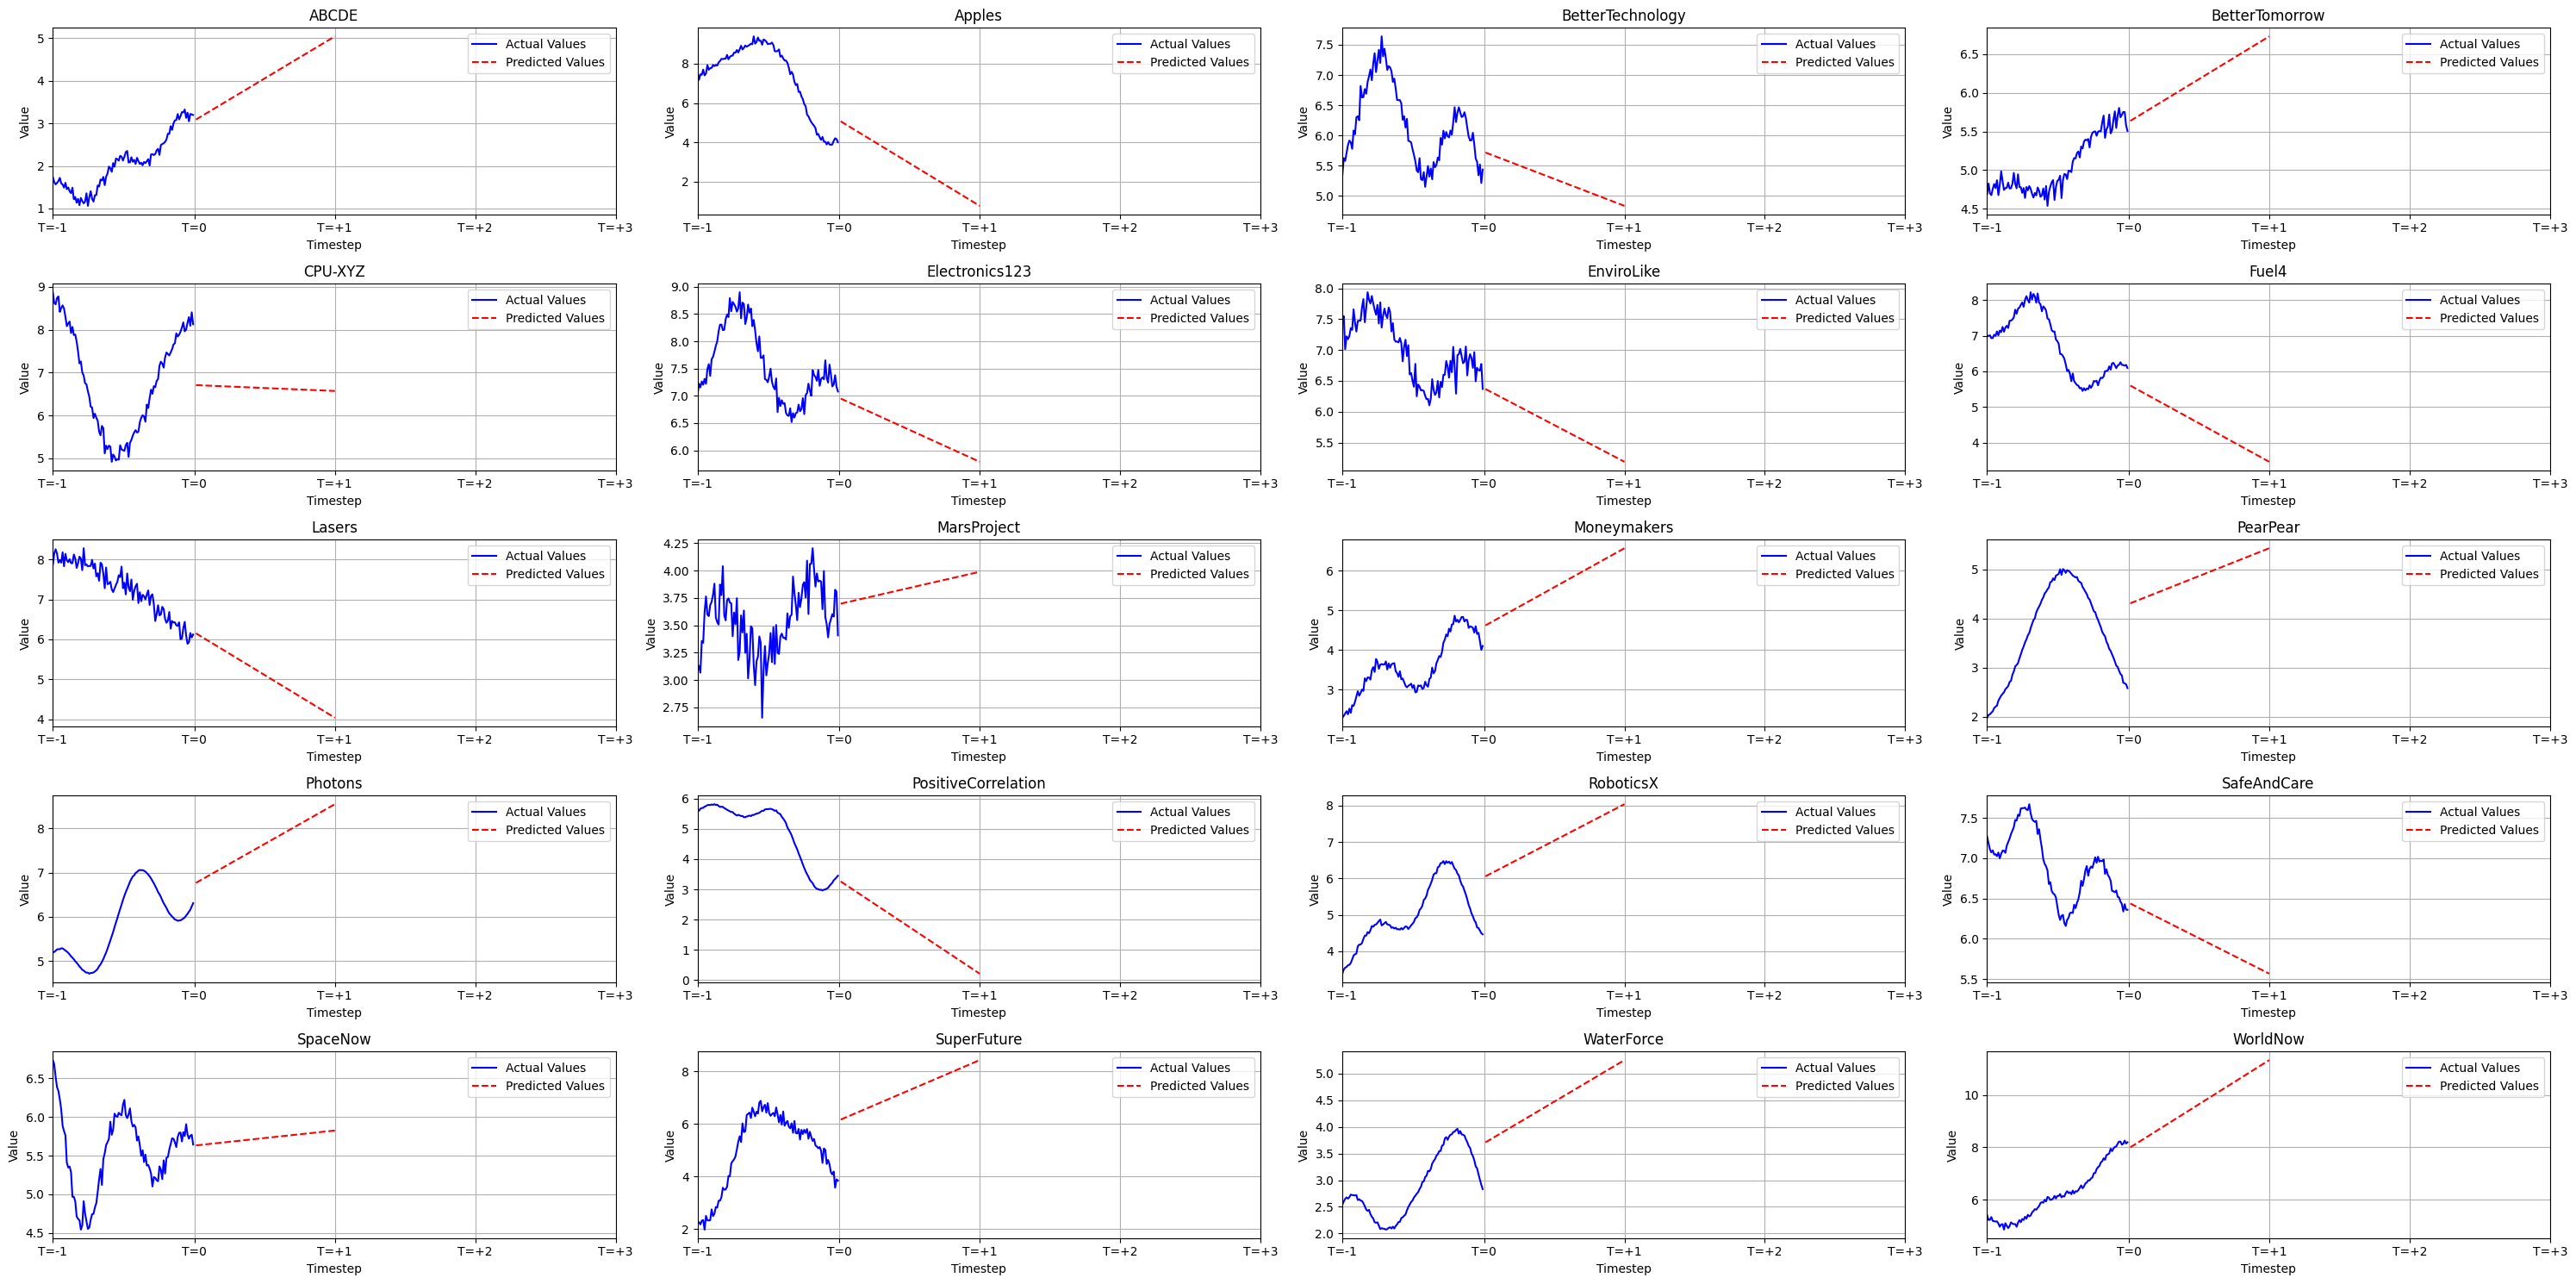

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

In [6]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, linear_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [ ]:
class GeneticSolver(Solver):
    def __init__(self, data, predicted_vals, risks, population_size, weight_size=20, num_dimensions=2):
        super().__init__(data, predicted_vals, risks)
        self.population_size = population_size  
        self.weight_size = weight_size
        self.log_history = False
        self.num_dimensions = num_dimensions

    def enable_loging(self):
        self.log_history = True
    
    def disable_loging(self):
        self.log_history = False

    def normalize(self, population):
        return population / population.sum(axis=1, keepdims=True)

    def generate_population(self):
        population = np.array([[random.random() for i in range(self.weight_size)].copy() for i in range(self.population_size)], dype=np.float32)
        population = self.normalize(population)
        print(population)
        if self.log_history:
            self.population_history = []
            self.population_history.append(population.copy) 
        return population
    
    def initialize_chebyshev(self):
        if self.num_dimensions <= 1:
            print("At least two dimensions must be present")
            raise ValueError
        elif self.num_dimensions == 2:
            samples_dim_1 = np.linspace(0, 1, self.population_size)
            samples_dim_2 = 1 - samples_dim_1
            weights = []
            for i in range(len(samples_dim_1)):
                weights.append([samples_dim_1[i], samples_dim_2[i]])
            weights = np.array(weights, dtype=np.float32)
        else:
            # Implement for 3 or more dimensions
            raise NotImplementedError
        return weights
    
    def find_neighborhoods(self, chebyshev_weights, neighborhood_size):
        distances = np.abs(chebyshev_weights[:, None] - chebyshev_weights).sum(axis=-1)
        neighbors_dict = {}
        for i, w in enumerate(chebyshev_weights):
            sorted_indices = np.argsort(distances[i])
            closest_indices = sorted_indices[1:neighborhood_size+1]
            neighbors_dict[tuple(w)] = [tuple(neighborhood_size[j]) for j in closest_indices]
        return neighbors_dict
    
    def assign_chebyshev_weights(self, population):
        chebyshev_weights = self.initialize_chebyshev()
        np.random.shuffle(chebyshev_weights)  # Shuffle for randomness
        weight_to_individual_map = {tuple(chebyshev_weights[i]): population[i] for i in range(self.population_size)}
        return weight_to_individual_map

    def genetic_optimize(self, generations=100, neighborhood_size=2):
        chebyshev_weights = self.initialize_chebyshev()
        self.neighborhoods = self.find_neighborhoods(chebyshev_weights, neighborhood_size)
        population = self.generate_population()
        weight_to_individual_map = self.assign_chebyshev_weights(population)
        for generation in generations:
            pass
            # Perform cross-over and mutation (only within neighborhood)
            # Assign children to closest chebyshev decomposition functions and choose the best candidates
        # Save the solutions

In [ ]:
import numpy as np

def find_closest_weights(weights, n_neighbors=2):
    weights = np.array(weights)
    distances = np.abs(weights[:, None] - weights).sum(axis=-1)  # Compute MAE distance
    
    neighbors_dict = {}
    for i, w in enumerate(weights):
        sorted_indices = np.argsort(distances[i])  # Sort indices based on MAE distance
        closest_indices = sorted_indices[1:n_neighbors+1]  # Exclude itself (index 0)
        neighbors_dict[tuple(w)] = [tuple(weights[j]) for j in closest_indices]
    
    return neighbors_dict

# Example usage
weights = [[1, 0], [0.75, 0.25], [0.5, 0.5], [0.25, 0.75], [0, 1]]
neighbors = find_closest_weights(weights, n_neighbors=2)
print(neighbors)


In [7]:
wsm_solutions_step_001 = solver.solve_wsm(step = 0.01)
wsm_solutions_step_025 = solver.solve_wsm(step = 0.25)
solutions = solver.solve_wsm()
wsm_solutions_step_01 = solutions.copy()

Running for w1=0.0, w2=1.0
     pcost       dcost       gap    pres   dres
 0: -8.7048e-01 -2.6320e+01  1e+02  2e+00  6e-16
 1: -2.8741e-01 -9.9388e+00  1e+01  2e-02  1e-15
 2: -2.9826e-01 -1.5342e+00  1e+00  2e-03  9e-16
 3: -4.5719e-01 -1.1052e+00  7e-01  5e-04  5e-16
 4: -5.7633e-01 -6.0454e-01  3e-02  2e-05  6e-16
 5: -5.8778e-01 -5.8813e-01  4e-04  2e-07  6e-16
 6: -5.8791e-01 -5.8792e-01  4e-06  2e-09  5e-16
 7: -5.8792e-01 -5.8792e-01  4e-08  2e-11  7e-16
Optimal solution found.
Running for w1=0.01, w2=0.99
     pcost       dcost       gap    pres   dres
 0: -8.0182e-01 -2.6076e+01  1e+02  2e+00  1e-15
 1: -2.7951e-01 -9.7801e+00  1e+01  2e-02  1e-15
 2: -2.9134e-01 -1.5009e+00  1e+00  2e-03  8e-16
 3: -4.5342e-01 -1.0106e+00  6e-01  3e-04  8e-16
 4: -5.5456e-01 -5.7947e-01  2e-02  1e-05  7e-16
 5: -5.6523e-01 -5.6550e-01  3e-04  1e-07  7e-16
 6: -5.6535e-01 -5.6535e-01  3e-06  1e-09  4e-16
 7: -5.6535e-01 -5.6535e-01  3e-08  1e-11  4e-16
Optimal solution found.
Running for w1=0

In [8]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,1.195354,2.033381,9.999999e-01,5.501224e-10,1.806255e-09,9.278324e-10,1.744569e-09,1.171034e-09,7.642277e-08,5.048926e-10,...,2.223069e-09,7.343016e-10,1.382181e-09,9.192784e-10,1.675905e-09,7.969685e-10,1.031651e-09,9.844784e-10,1.474305e-09,1.0
1,1.075396,0.698090,9.857620e-07,4.049649e-09,1.520894e-08,7.057620e-09,7.611367e-09,7.592235e-09,8.757694e-01,4.307230e-09,...,4.322640e-08,6.029597e-09,1.012226e-08,1.246136e-08,4.503800e-08,5.823809e-09,1.242294e-01,7.437485e-09,1.081241e-08,1.0
2,0.990862,0.368846,1.088280e-07,7.560538e-09,1.641749e-08,1.591038e-08,1.490756e-08,1.422991e-08,5.414350e-01,7.169736e-09,...,3.215390e-08,1.313593e-08,1.797984e-08,1.310190e-08,3.367682e-08,1.198763e-08,4.585646e-01,1.467883e-08,1.719202e-08,1.0
3,0.962683,0.315378,3.739443e-08,1.132824e-08,9.530306e-09,6.732808e-08,8.648365e-09,1.583410e-08,4.299885e-01,9.178956e-09,...,6.354127e-08,5.683859e-08,2.825492e-08,4.079034e-08,1.592340e-08,2.541272e-08,5.700109e-01,3.461003e-08,1.785398e-08,1.0
4,0.898422,0.251836,1.088526e-08,7.011484e-09,4.232628e-09,3.756868e-08,3.841862e-09,9.365273e-09,3.559531e-01,5.627756e-09,...,2.784086e-08,3.540168e-02,1.852594e-08,3.818455e-08,7.400925e-09,2.244106e-08,6.086449e-01,2.741964e-08,9.663951e-09,1.0
5,0.721897,0.119840,6.607936e-09,6.593258e-09,4.080154e-09,7.382826e-09,3.732494e-09,9.250490e-09,2.776464e-01,5.534584e-09,...,1.241590e-08,1.454464e-01,1.385431e-08,1.450190e-02,5.675607e-09,2.190107e-08,5.624051e-01,1.683988e-08,8.754595e-09,1.0
6,0.591463,0.054709,4.454778e-09,2.075153e-09,2.249676e-09,8.049842e-08,2.217403e-09,3.518344e-09,3.517747e-01,1.964370e-09,...,7.714980e-09,1.598369e-01,5.681660e-09,1.394984e-01,3.603220e-09,4.563057e-09,3.488898e-01,5.974902e-09,4.040393e-09,1.0
7,0.498295,0.024138,3.761121e-09,8.616074e-10,1.876928e-09,1.560509e-07,1.538670e-09,1.424117e-09,4.047289e-01,1.080381e-09,...,1.172975e-08,1.701133e-01,4.852002e-09,2.287867e-01,2.788890e-09,5.512013e-10,1.963709e-01,5.823877e-09,3.245482e-09,1.0
8,0.428419,0.009932,6.535234e-09,7.756373e-10,2.725618e-09,4.760181e-07,1.022847e-09,1.233277e-09,4.444446e-01,8.011827e-10,...,2.671311e-08,1.778203e-01,6.594808e-09,2.957529e-01,3.307208e-09,1.791551e-09,8.198158e-02,7.796010e-09,4.462657e-09,1.0
9,0.374554,0.004086,1.451061e-08,2.420713e-09,1.548949e-08,1.286970e-06,4.120533e-09,1.549325e-08,4.703447e-01,2.840945e-09,...,4.375538e-08,1.859726e-01,1.185907e-08,3.434592e-01,5.507888e-09,7.419960e-09,1.822771e-05,9.359661e-09,1.546086e-08,1.0


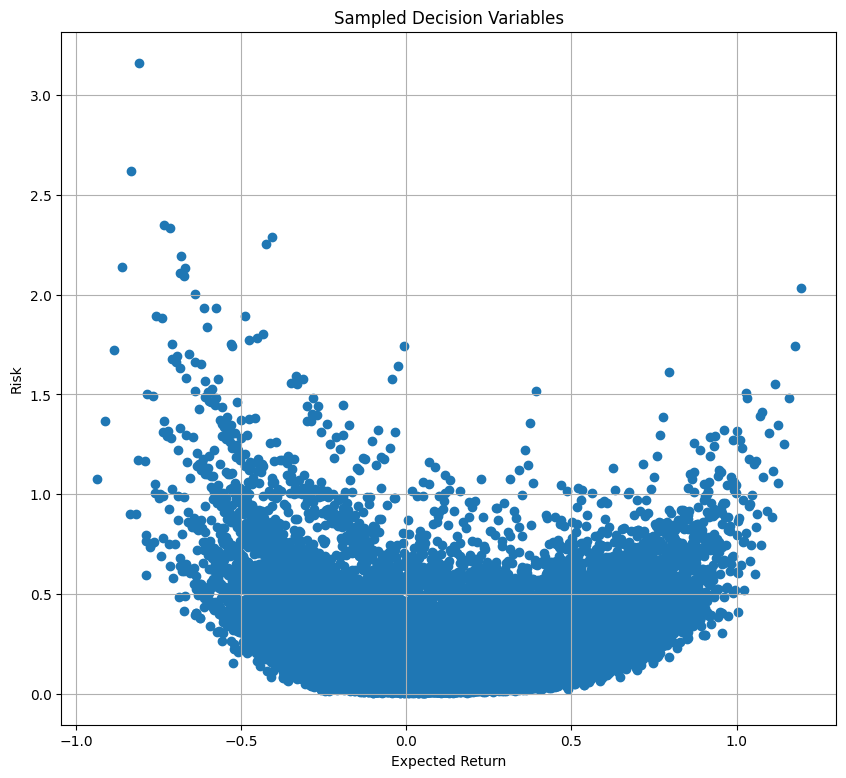

In [9]:
solver.plot_sampled_decision_variables(20, 0.2)

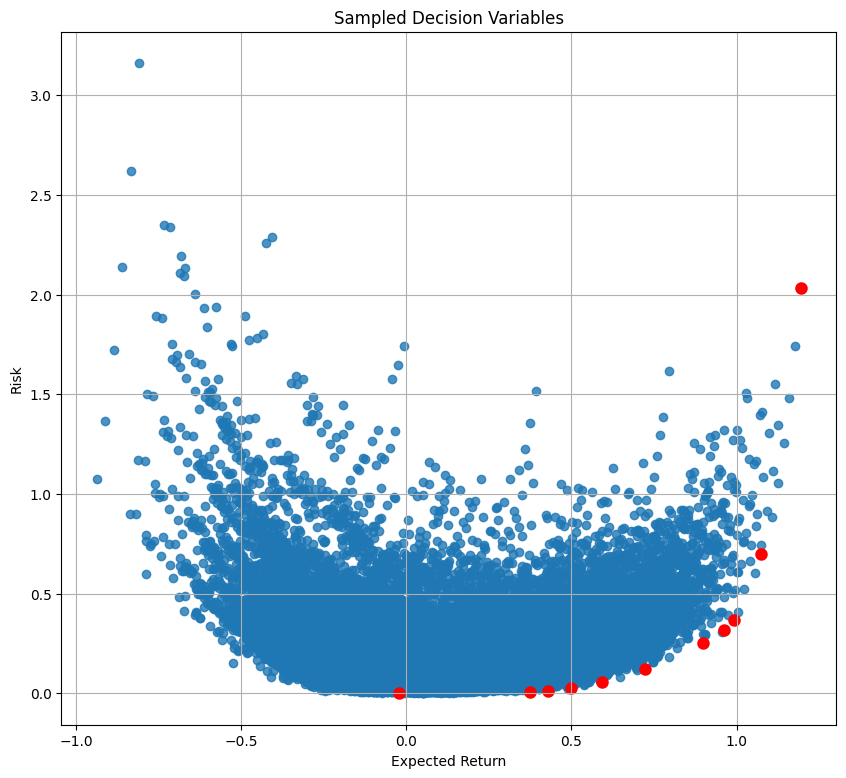

In [10]:
solver.plot_front(solutions, n=20, step=0.2)